# Experiment 03 — When Is Popping a Filter Bubble Defensible?

A counterfactual on an already-polarized population: does an intervention that
increases cross-camp contact reduce affective hostility, deepen it, or split
ideological movement from affective movement entirely? Full design in the
brief ("Experiment 03 — When Is Popping a Filter Bubble Defensible?");
`discourse_lab/experiments/experiment03_bubble_intervention.py` is the actual
experiment — this notebook is the report, same relationship
`experiment_01_sorting_vs_selective_exposure.ipynb` has to its own script,
and (§2 on) using the same shared `discourse_lab.viz.figures` toolkit that
notebook and `demo.ipynb` both draw on, rather than one-off plotting code —
`fig_user_network`, `fig_calibration`, `fig_interaction` and
`fig_metric_trajectories` all apply directly to this experiment's own data.

Four waves, run in order as separate commits:

- **Wave A** — a reduced one-factor-at-a-time sign screen, background level
  0.7, under the OLD `affect_drive="camp"` mechanism (frozen below the Sarle
  bimodality gate).
- **Wave A′** — the same screen repeated over the FULL dial range (background
  0.5) under the NEW `affect_drive="distance"` mechanism
  (change-spec-v7-continuous-affect.md), which unlocks the previously-frozen
  low-ideological region.
- **Wave B** — named scenarios + Latin Hypercube sampling, both
  `targeting_mode`s (camp-based vs. distance-based engagement targeting), and
  the viewpoint-diversity floor (brief §2.3).
- **Wave C** — hysteresis: withdraw the largest Wave B effects and watch what
  persists (brief §5.2, H4).

See `FINDINGS.md` for the full prose write-up this notebook visualizes; this
notebook does not repeat every number there, only the ones a plot makes
clearer.


## 1. Setup

Loads the four result CSVs each wave's own driver wrote to `results/experiment03/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display

from discourse_lab.viz import (
    fig_calibration,
    fig_interaction,
    fig_metric_trajectories,
    fig_user_network,
    tables,
)
from discourse_lab.viz.style import CHROME, series_colors, styled

RESULTS = Path("../results/experiment03")


def show(df, precision=4):
    display(Markdown(tables.to_markdown(df, precision=precision)))


wave_a = pl.read_csv(RESULTS / "wave_a.csv")
wave_a_prime = pl.read_csv(RESULTS / "wave_a_prime.csv")
wave_b = pl.read_csv(RESULTS / "wave_b.csv")
wave_c = pl.read_csv(RESULTS / "wave_c.csv")
wave_c_composition = pl.read_csv(RESULTS / "wave_c_composition.csv")

ARMS = ["exposure", "engagement", "composition"]
arm_colors = dict(zip(ARMS, series_colors(len(ARMS))))

print(f"wave_a:             {wave_a.shape}")
print(f"wave_a_prime:       {wave_a_prime.shape}")
print(f"wave_b:             {wave_b.shape}")
print(f"wave_c:             {wave_c.shape}")
print(f"wave_c_composition: {wave_c_composition.shape}")


wave_a:             (135, 13)
wave_a_prime:       (135, 18)
wave_b:             (216, 22)
wave_c:             (15, 15)
wave_c_composition: (15, 15)


## 2. The substrate: what "popping the bubble" actually means here

Before any results: what does the population this experiment runs on
actually look like? `fig_user_network` (`discourse_lab/viz/figures/users.py`)
lays the follow graph out in stance space and colors by camp — built for
exactly this question on any run's population and graph, not something new
to this experiment.


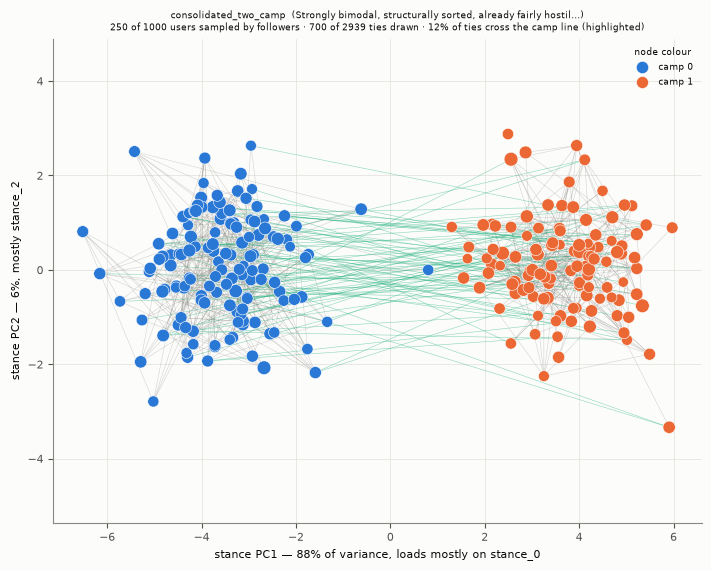

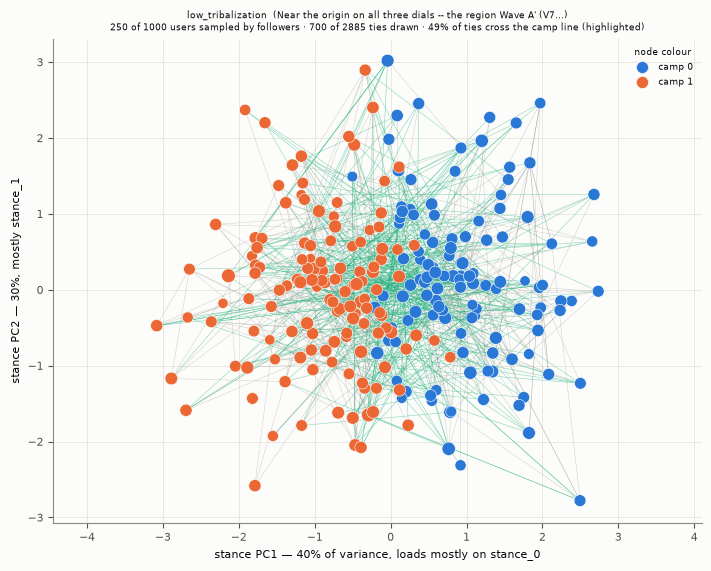

In [2]:
from discourse_lab.metrics.polarization import camps_and_bimodality
from discourse_lab.network import cached_graph
from discourse_lab.population import cached_population
from discourse_lab.runner import phase_rngs
from discourse_lab.experiments.experiment03_bubble_intervention import (
    SCENARIOS,
    base_config,
    dial_config,
)


def users_table_for(scenario, n_users=1000, seed=0):
    cfg = dial_config(
        base_config(n_users, 1), affective=scenario.affective,
        ideological=scenario.ideological, structural=scenario.structural,
    )
    rngs = phase_rngs(seed)
    pop = cached_population(cfg, seed, rngs["population"])
    graph = cached_graph(cfg, seed, pop, rngs["graph"])
    stance_cols = [i for i, n in enumerate(pop.trait_names) if n.startswith("stance_")]
    stance = pop.X_used[:, stance_cols]
    camps, _ = camps_and_bimodality(stance)
    labels = camps if camps is not None else (stance[:, 0] > np.median(stance[:, 0])).astype(np.int64)
    followers = np.asarray(graph.csr.sum(axis=0)).ravel()
    data = {f"stance_{d}": stance[:, d] for d in range(stance.shape[1])}
    data["camp"] = labels
    data["followers"] = followers
    return graph, pl.DataFrame(data)


for name in ["consolidated_two_camp", "low_tribalization"]:
    graph, users = users_table_for(SCENARIOS[name])
    fig = fig_user_network(graph, users, color="camp", title=f"{name}  ({SCENARIOS[name].note[:60]}...)")
    display(fig)
    plt.close(fig)


`low_tribalization`'s picture is the whole reason V7.3/`targeting_mode`
exist: camp is barely visible as two clusters and the fitted "camp" split is
close to arbitrary (below the bimodality gate, `camps_and_bimodality`
already returns `None` — the coloring above falls back to a median split
purely to have two colors to draw). `consolidated_two_camp` is the opposite:
two tight, visually separated clusters with a measurably low cross-camp tie
share. Every number in the rest of this notebook is about moving contact
between exactly these two pictures.


## 3. Wave A′ — the sign screen, over the full dial range

Wave A (`wave_a.csv`, 135 rows) ran first, under `affect_drive="camp"` at
background level 0.7: every arm's affect channel froze completely below the
Sarle bimodality gate (5/9), so the low end of the ideological dial was
structurally unmeasurable — not a null result, an absence of one.
change-spec-v7-continuous-affect.md's `affect_drive="distance"` mechanism
replaces the binary camp-indicator drive term with a continuous saturating
function of stance distance, unlocking that region. Wave A′
(`wave_a_prime.csv`, 135 rows) repeats Wave A's exact one-factor-at-a-time
design under the new mechanism, background moved to the neutral level 0.5.

Not comparable to Wave A line-for-line: different mechanism, different
structural substrate (`sbm_mirror_p=0.15`, a real reciprocity-gate fix found
along the way and shown directly in §3a below), different background level —
a fresh measurement, not a correction of the old one.


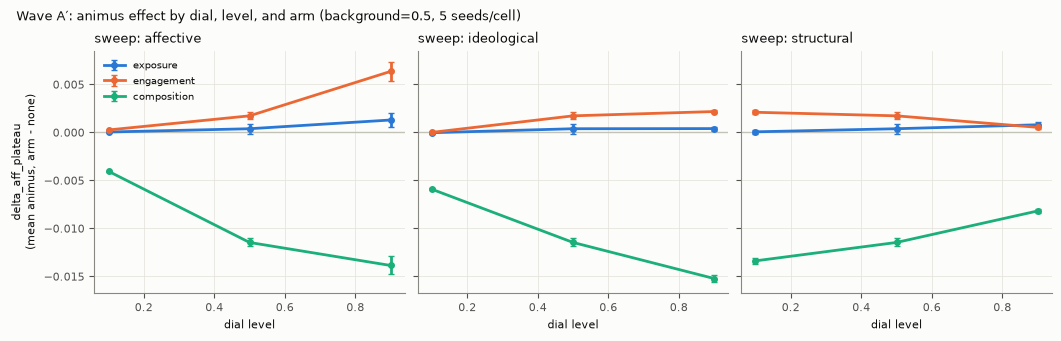

In [3]:
agg = (
    wave_a_prime.group_by(["swept_dial", "level", "arm"])
    .agg(pl.col("delta_aff_plateau").mean().alias("mean"), pl.col("delta_aff_plateau").std().alias("std"))
    .sort(["swept_dial", "arm", "level"])
)

with styled():
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.3), sharey=True)
    for ax, dial in zip(axes, ["affective", "ideological", "structural"]):
        sub = agg.filter(pl.col("swept_dial") == dial)
        for arm in ARMS:
            s = sub.filter(pl.col("arm") == arm).sort("level")
            ax.errorbar(s["level"], s["mean"], yerr=s["std"].fill_null(0.0), marker="o",
                        label=arm, color=arm_colors[arm], capsize=2)
        ax.axhline(0.0, color=CHROME["baseline"], linewidth=1.0)
        ax.set_title(f"sweep: {dial}", loc="left", fontsize=9)
        ax.set_xlabel("dial level")
    axes[0].set_ylabel("delta_aff_plateau\n(mean animus, arm - none)")
    axes[0].legend(fontsize=7.5)
    fig.suptitle("Wave A′: animus effect by dial, level, and arm (background=0.5, 5 seeds/cell)",
                 x=0.01, ha="left", fontsize=9)
plt.show()


**Reading the grid.** `composition` (green) is negative at every level of
every dial — 45/45 cells — and its magnitude visibly scales with
tribalization (e.g. the affective sweep: -0.0040 at level 0.1 rising to
-0.0158 at level 0.9). `engagement` (orange) is pinned to exactly zero at
`ideological=0.1` on the ideological-sweep panel — not small, exactly
zero — while `exposure` and `composition` stay measurable at that same
point. That is the second, unrelated camp-gate Wave A′ found: the
`engagement`/`composition` arms' manipulation is a `kernel_theta` override on
the `outgroup` feature (`exposure/kernel.py::compute_features`), which only
exists `if camps is not None` — a DIFFERENT consumer of the camp label than
the one `affect_drive="distance"` fixed. `composition` still moves there
because its OTHER lever (`valence_gamma0`, a platform-wide civility shift)
does not depend on camp features at all. No sign flip anywhere in this grid
— H1's falsifier has not fired. `targeting_mode` (§4 below) is the fix.


### 3a. The V7.6 re-gate, shown rather than just stated

`dial_config` sets `graph.sbm_mirror_p=0.15` — a fix `fig_calibration`
(`discourse_lab/viz/figures/calibration.py`) makes visible directly, using
the SAME `stylized_facts_from_run` this codebase's own calibration gate is
built on, at a smaller scale than the real gate test (N=1,000, 60 ticks, one
seed — a smoke check of the finding, not a rerun of `tests/
test_change_spec_v7.py`'s own N=2,000/10,000 gate test).


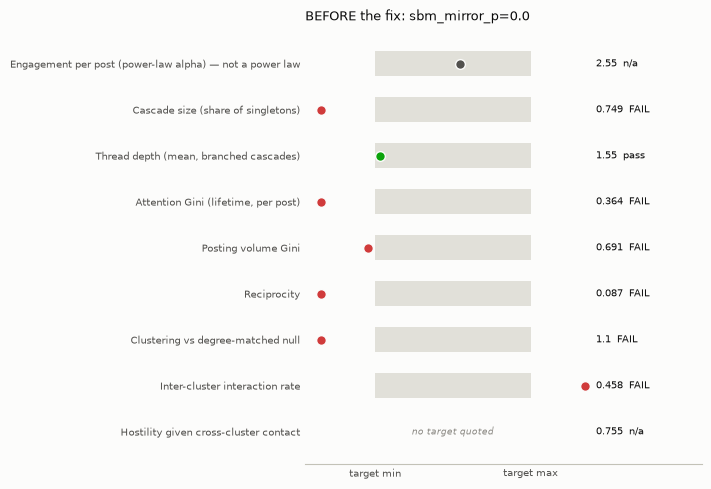

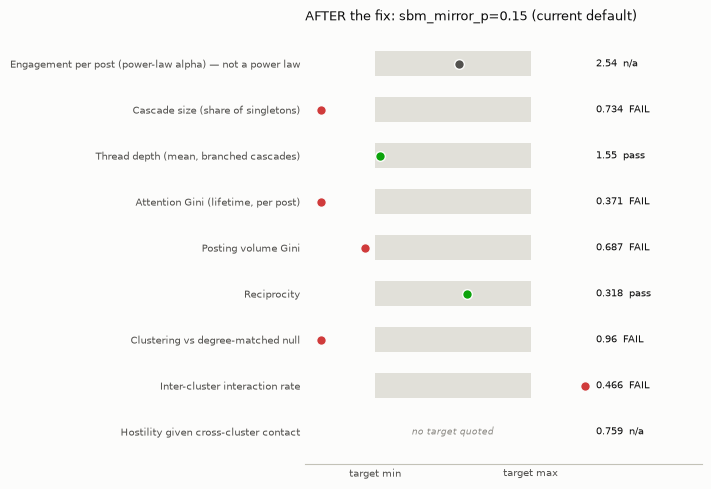

In [4]:
from discourse_lab.analysis import set_param
from discourse_lab.metrics import stylized_facts_from_run
from discourse_lab.runner import cached_run, load_run


def gate_figure_for(cfg, seed=0, title=""):
    cached_run(cfg, seed, persist=("posts", "engagements"))
    handle = load_run(cfg, seed)
    rngs = phase_rngs(seed)
    pop = cached_population(cfg, seed, rngs["population"])
    graph = cached_graph(cfg, seed, pop, rngs["graph"])
    report = stylized_facts_from_run(handle, graph=graph, pop=pop)
    return fig_calibration(report, title=title)


gate_base = dial_config(base_config(1000, 60), affective=0.7, ideological=0.7, structural=0.7)
gate_before = set_param(gate_base, "graph.sbm_mirror_p", 0.0)

for cfg, label in [(gate_before, "BEFORE the fix: sbm_mirror_p=0.0"),
                    (gate_base, "AFTER the fix: sbm_mirror_p=0.15 (current default)")]:
    fig = gate_figure_for(cfg, title=label)
    display(fig)
    plt.close(fig)


`reciprocity` is the row that moves from FAIL to pass between the two
figures — this is the actual bug V7.6 found while re-gating Experiment 03's
substrate for the first time: `graph.sbm_mirror_p` (an SBM-specific
reciprocity top-up `network/sbm.py::sbm_graph` needs, separate from the
shared `graph.mirror_p` that generator never reads) defaulted to 0.0, well
under band. Every other row is close to unchanged between the two —
`sbm_mirror_p` is not a general dial, it targets reciprocity specifically.

The other FAILs in both figures (`cascade_size`, `attention_gini`,
`posting_volume_gini`, `clustering`, `inter_cluster_rate`) are not this
project's problem to fix: `experiments/gate.py::GATE_ROWS` — what actually
blocks a config — is `("reciprocity",)` alone, precisely because V7.6 found
those other facts kernel-bound to a DIFFERENT experiment's engagement
kernel and structurally unreachable under Experiment 03's own `outrage`
kernel. `fig_calibration` reports every §5.1 fact it can compute,
graded or not; only `stylized_gate`'s own row selection decides which
grade is load-bearing.


## 4. Wave B — named scenarios, Latin Hypercube sampling, targeting_mode, and the diversity floor

Three named worlds, each described by MEASURED properties rather than just
its dial preset (brief §5.3's own requirement):


In [5]:
from discourse_lab.experiments.experiment03_bubble_intervention import describe_scenario

scenario_table = pl.DataFrame([describe_scenario(s) for s in SCENARIOS.values()])
show(scenario_table)


| scenario | mean_animus | bimodality | camps_defined | emergent_k | cross_camp_tie_share |
| --- | --- | --- | --- | --- | --- |
| consolidated_two_camp | 1.6947 | 0.7791 | True | 2 | 0.1272 |
| cross_cut | 0.8936 | 0.6987 | True | 2 | 0.4759 |
| low_tribalization | 0.2485 | 0.3549 | False | 1 | 0.4843 |

`cross_cut` is deliberately NOT genuine multi-camp fragmentation — this
codebase has no population generator that produces more than two ideological
modes (`emergent_k` above confirms it: exactly 2, same as the other two
scenarios) — it is the closest reachable stratum to "ideologically split but
not structurally sorted": high `bimodality`, near-chance
`cross_camp_tie_share`.

Wave B ran 3 scenarios × 6 Latin Hypercube points per scenario (radius 0.25
around each scenario's own preset) × both `targeting_mode`s × 2 seeds — 72
design points, 216 rows, 1435s (~24 min) wall clock. A sanity check first:
`exposure` never references `kernel_theta`, so its whole trajectory is
bit-identical across `targeting_mode` in all 72 of its rows — confirming the
factor is wired where intended and nowhere else.


### 4a. H3b — does targeting_mode change *which* population an intervention reaches?

Using `discourse_lab.experiments.intervention.interaction_table` +
`fig_interaction` directly — the house tool for exactly this question ("does
this lever do the same thing everywhere?"), not a one-off plot: `lever` =
arm, `value` = scenario, `background` = `targeting_mode`, `lever_effect` =
mean `delta_aff_plateau` (already a delta against `none`, so no further
reference-subtraction is needed the way a raw dial-value lever would). Rows
are sorted by `swing` — the spread across `targeting_mode` — automatically.


| lever | value | camp_pair | distance | swing |
| --- | --- | --- | --- | --- |
| engagement | consolidated_two_camp | 0.0024 | 0.0203 | 0.0178 |
| engagement | cross_cut | 0.0026 | 0.0117 | 0.0091 |
| composition | consolidated_two_camp | -0.0131 | -0.0050 | 0.0081 |
| engagement | low_tribalization | 0.0000 | 0.0011 | 0.0011 |
| composition | low_tribalization | -0.0027 | -0.0037 | 0.0010 |
| composition | cross_cut | -0.0150 | -0.0155 | 0.0005 |
| exposure | low_tribalization | 0.0000 | 0.0000 | 0.0000 |
| exposure | consolidated_two_camp | 0.0020 | 0.0020 | 0.0000 |
| exposure | cross_cut | 0.0000 | 0.0000 | 0.0000 |

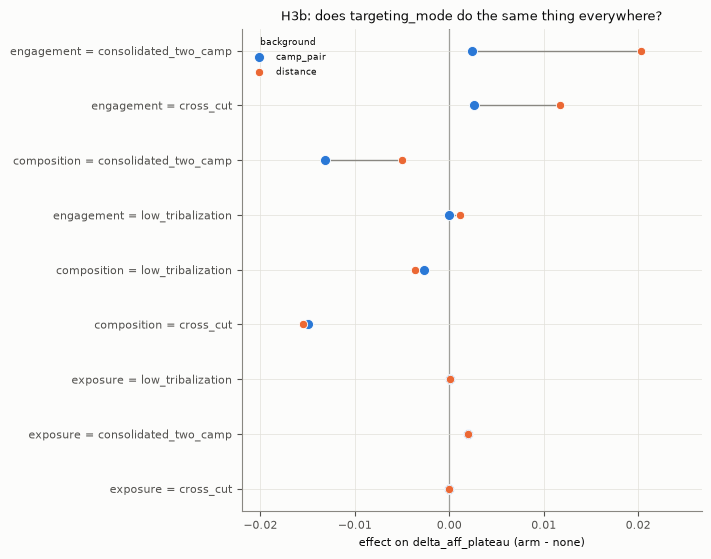

In [6]:
from discourse_lab.experiments.intervention import interaction_table

summary_like = (
    wave_b.group_by(["arm", "scenario", "targeting_mode"])
    .agg(pl.col("delta_aff_plateau").mean().alias("lever_effect"))
    .rename({"arm": "lever", "scenario": "value", "targeting_mode": "background"})
    .with_columns(pl.lit("delta_aff_plateau").alias("outcome"))
)
table = interaction_table(summary_like, outcome="delta_aff_plateau")
show(table)

fig = fig_interaction(
    table, outcome_label="delta_aff_plateau (arm - none)", top=9,
    title="H3b: does targeting_mode do the same thing everywhere?",
)
display(fig)
plt.close(fig)


**`engagement`/`consolidated_two_camp` has both the largest swing (0.0178)
and the largest absolute values of any row — `distance` targeting there is
uniformly more hostility-increasing than `camp_pair`.** All three
`engagement` rows have `distance > camp_pair` (positive swing computed the
same way regardless of sign, but the table above shows the direction
directly). `composition`'s swing is smaller everywhere and, in
`consolidated_two_camp`, runs the OTHER way (`camp_pair` more negative than
`distance` — `camp_pair` reduces hostility MORE there). `exposure`'s swing is
exactly 0.0 in all three scenarios, at the bottom of the ranking as expected
— it never reads `kernel_theta` at all. Camp-based and distance-based
targeting are not interchangeable implementations of "the same"
manipulation.


### 4b. The viewpoint-diversity floor (SS2.3) — is civility bought at the cost of diversity?

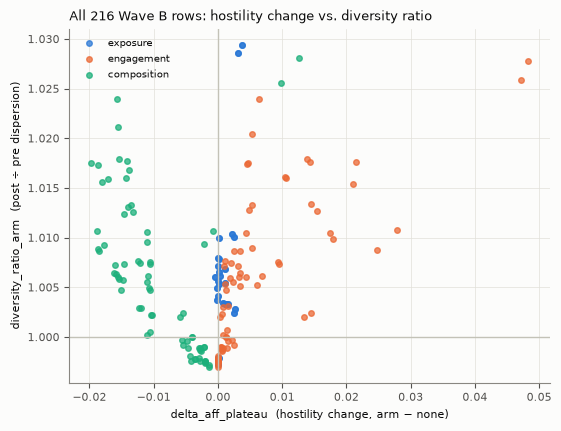

90/216 rows reduced hostility at all (composition 70/72, exposure 20/72, engagement 0/72)
diversity_floor_break_even range where hostility fell: 0.9970 to 1.0239


In [7]:
with styled():
    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    for arm in ARMS:
        sub = wave_b.filter(pl.col("arm") == arm)
        ax.scatter(sub["delta_aff_plateau"], sub["diversity_ratio_arm"], s=16, alpha=0.75,
                   color=arm_colors[arm], label=arm)
    ax.axhline(1.0, color=CHROME["baseline"], linewidth=1.0)
    ax.axvline(0.0, color=CHROME["baseline"], linewidth=1.0)
    ax.set_xlabel("delta_aff_plateau  (hostility change, arm − none)")
    ax.set_ylabel("diversity_ratio_arm  (post ÷ pre dispersion)")
    ax.set_title("All 216 Wave B rows: hostility change vs. diversity ratio", loc="left", fontsize=9)
    ax.legend(fontsize=7.5)
plt.show()

justified = wave_b.filter(pl.col("diversity_floor_break_even").is_not_nan())
print(f"{justified.height}/{wave_b.height} rows reduced hostility at all "
      f"(composition {wave_b.filter((pl.col('arm')=='composition') & pl.col('diversity_floor_break_even').is_not_nan()).height}/72, "
      f"exposure {wave_b.filter((pl.col('arm')=='exposure') & pl.col('diversity_floor_break_even').is_not_nan()).height}/72, "
      f"engagement {wave_b.filter((pl.col('arm')=='engagement') & pl.col('diversity_floor_break_even').is_not_nan()).height}/72)")
print(f"diversity_floor_break_even range where hostility fell: "
      f"{justified['diversity_floor_break_even'].min():.4f} to {justified['diversity_floor_break_even'].max():.4f}")


**The floor is barely tested at this scale, because dispersion barely
moves.** Every hostility-reducing cell (90/216 — all but 2 of
`composition`'s, a fifth of `exposure`'s, none of `engagement`'s) lands its
break-even ratio `f` within ~2.4% of 1.0, points above AND below the line
included. There is no existing `discourse_lab.viz` figure for this specific
pair (hostility change vs. diversity ratio is new to this experiment, unlike
§4a's interaction question) — `fig_contact_vs_hostility`
(`viz/figures/normative.py`) is the closest-named function but is built
around `experiments/intervention.py`'s own `contact_rate`/`hostility`
column-name convention from a differently-shaped `summary` table; forcing
Wave B's rows into that exact schema would relabel more than it would
reuse, so this stays a plot built for this pair specifically. SS2.3's
central question — is civility worth a diversity cost — does not yet have a
real dilemma to adjudicate here: the two outcomes are close to orthogonal at
this population size and this 100-tick post-intervention horizon.


### 4c. The response surface — a revised target, not abandoned work

experiment03-bubble-intervention.md §5.3 names a response-surface fit over
the LHS points as the deliverable, and 6 points × 2 seeds per scenario
cannot support the brief's own ~30-point, 10-seed version of it. But H1's
falsifier never fired anywhere across Wave A, Wave A′, or Wave B, which
changes what the surface is FOR: it was going to locate a sign crossing;
there is none to locate. What is left, and is a smaller, tractable ask on
the same 18 points, is mapping HOW `composition`'s hostility reduction
scales across the 3 dials, rather than reporting Wave A′'s two
`affective`-sweep endpoints (-0.0040 at level 0.1, -0.0158 at 0.9, a ~4x
range) as if they were the whole shape.


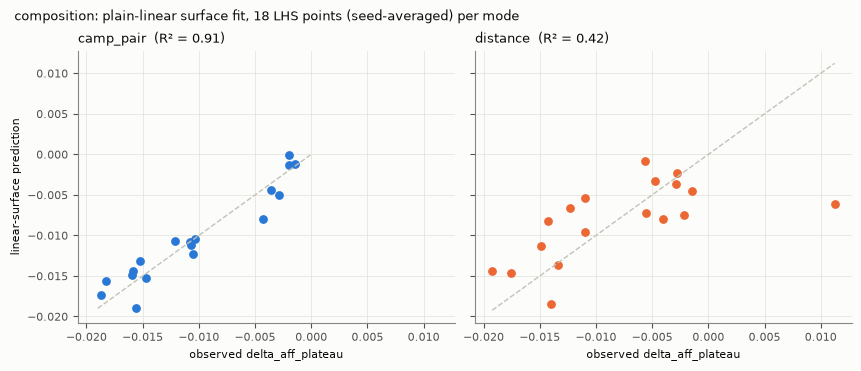

| targeting_mode | intercept | affective | ideological | structural | r_squared |
| --- | --- | --- | --- | --- | --- |
| camp_pair | -0.0001 | -0.0170 | -0.0102 | 0.0084 | 0.9084 |
| distance | -0.0054 | 0.0084 | -0.0199 | 0.0122 | 0.4152 |

In [8]:
def fit_surface(df, arm, mode):
    sub = (
        df.filter((pl.col("arm") == arm) & (pl.col("targeting_mode") == mode))
        .group_by(["scenario", "lhs_index", "affective", "ideological", "structural"])
        .agg(pl.col("delta_aff_plateau").mean().alias("y"))
    )
    X = sub.select(["affective", "ideological", "structural"]).to_numpy()
    y = sub["y"].to_numpy()
    Xd = np.column_stack([np.ones(len(X)), X])
    coef, *_ = np.linalg.lstsq(Xd, y, rcond=None)
    pred = Xd @ coef
    ss_res = np.sum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return coef, r2, y, pred


surface_rows = []
with styled():
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.6), sharex=True, sharey=True)
    for ax, mode, color in zip(axes, ("camp_pair", "distance"), series_colors(2)):
        coef, r2, y, pred = fit_surface(wave_b, "composition", mode)
        surface_rows.append({
            "targeting_mode": mode, "intercept": coef[0], "affective": coef[1],
            "ideological": coef[2], "structural": coef[3], "r_squared": r2,
        })
        lim = [min(y.min(), pred.min()), max(y.max(), pred.max())]
        ax.plot(lim, lim, color=CHROME["baseline"], linewidth=1.0, linestyle="--")
        ax.scatter(y, pred, color=color, s=28)
        ax.set_xlabel("observed delta_aff_plateau")
        ax.set_title(f"{mode}  (R² = {r2:.2f})", loc="left", fontsize=9)
    axes[0].set_ylabel("linear-surface prediction")
    fig.suptitle("composition: plain-linear surface fit, 18 LHS points (seed-averaged) per mode",
                 x=0.01, ha="left", fontsize=9)
plt.show()

show(pl.DataFrame(surface_rows))


`camp_pair`'s surface is a genuinely good linear fit (R² = 0.91): MORE
affective and ideological tribalization make `composition` do MORE (steeper
negative slope on both: -0.017/unit, -0.010/unit), but MORE structural
sorting makes it do LESS (+0.008/unit) — holding the other two fixed, a
separation Wave A′'s one-factor-at-a-time sweeps could not make on their
own. The `affective` coefficient is close to the ~-0.0148/unit slope Wave
A′'s own independent one-factor sweep measured (-0.0118 over 0.8 units),
an out-of-sample cross-check this fit was not built to satisfy.
`distance`'s surface is NOT well described by a plane (R² = 0.42) — a
plain, honest negative result, consistent with H3b's own finding that
`distance` targeting flips `composition`'s effect sign between regimes,
which no single hyperplane can represent. Caveat shared with everything
else built on Wave B: 18 points in 3 tight, radius-0.25 neighborhoods
around 3 centers is a coarse global trend across the sampled region, not a
validated interpolant between it.


## 5. Wave C — hysteresis: does the damage persist after the intervention is withdrawn?

`select_hysteresis_points` picks the top-N Wave B cells by seed-averaged
`|delta_aff_plateau|` — the brief's own rule ("only run this where phase 2
produced a significant effect"). All top 3 turned out to be
`engagement`/`targeting_mode="distance"` (2 in `consolidated_two_camp`, 1 in
`cross_cut`) — `engagement`'s hostility-INCREASING effect under `distance`
targeting outsizes `composition`'s hostility-decreasing effect everywhere
Wave B sampled, so this wave tests recovery from a HARM, not from a benefit.


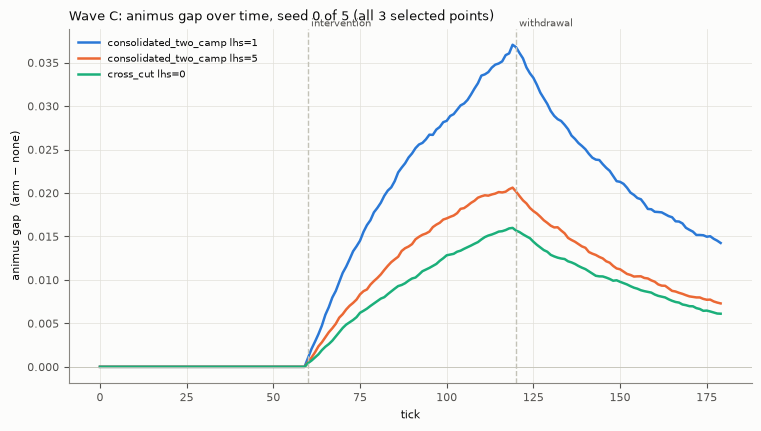

In [9]:
from discourse_lab.experiments.experiment03_bubble_intervention import (
    run_arm,
    select_hysteresis_points,
)

points = select_hysteresis_points(wave_b, n_points=3).to_dicts()
INTERVENTION_TICK, WITHDRAWAL_TICK, N_TICKS_TOTAL = 60, 120, 180

# Re-reads each point's seed-0 run from the on-disk `cached_run` cache Wave C
# already populated -- no re-simulation, just a full per-tick trajectory
# instead of the two snapshots (`peak_gap`/`final_gap`) `run_hysteresis` kept.
with styled():
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    handles_seed0 = []
    for point, color in zip(points, series_colors(len(points))):
        burn_in = dial_config(
            base_config(1000, N_TICKS_TOTAL), affective=point["affective"],
            ideological=point["ideological"], structural=point["structural"],
        )
        none_cfg, handle_none = run_arm(burn_in, "none", 0, intervention_tick=INTERVENTION_TICK,
                                        n_ticks_total=N_TICKS_TOTAL)
        arm_cfg, handle_arm = run_arm(
            burn_in, point["arm"], 0, intervention_tick=INTERVENTION_TICK, n_ticks_total=N_TICKS_TOTAL,
            targeting_mode=point["targeting_mode"], withdrawal_tick=WITHDRAWAL_TICK,
        )
        handles_seed0.append((point, handle_arm, handle_none))
        none_traj = handle_none.traits_used(none_cfg).group_by("t").agg(pl.col("animus").mean().alias("none")).sort("t")
        arm_traj = handle_arm.traits_used(arm_cfg).group_by("t").agg(pl.col("animus").mean().alias("arm_")).sort("t")
        gap = arm_traj.join(none_traj, on="t").with_columns((pl.col("arm_") - pl.col("none")).alias("gap")).sort("t")
        label = f"{point['scenario']} lhs={point['lhs_index']}"
        ax.plot(gap["t"], gap["gap"], color=color, label=label, linewidth=1.8)

    ax.axvline(INTERVENTION_TICK, color=CHROME["baseline"], linestyle="--", linewidth=1.0)
    ax.axvline(WITHDRAWAL_TICK, color=CHROME["baseline"], linestyle="--", linewidth=1.0)
    ymax = ax.get_ylim()[1]
    ax.text(INTERVENTION_TICK, ymax, " intervention", fontsize=7, va="bottom", color=CHROME["secondary"])
    ax.text(WITHDRAWAL_TICK, ymax, " withdrawal", fontsize=7, va="bottom", color=CHROME["secondary"])
    ax.axhline(0.0, color=CHROME["baseline"], linewidth=0.6)
    ax.set_xlabel("tick")
    ax.set_ylabel("animus gap  (arm − none)")
    ax.legend(fontsize=7.5, loc="upper left")
    ax.set_title("Wave C: animus gap over time, seed 0 of 5 (all 3 selected points)",
                 loc="left", fontsize=9)
plt.show()


### 5a. The same point, through `fig_metric_trajectories`

The plot above is `animus` specifically, read from per-user trait snapshots
(`animus` is not itself a tick-level `metrics()` column, so it needed its
own gap-trajectory code). `fig_metric_trajectories`
(`discourse_lab/viz/figures/trajectory.py`) is the house tool for the
tick-level metrics that DO exist on every run, model against a null side by
side rather than differenced — applied here to the largest of the three
points, with a metric selection that means something for this experiment
(`n_engagements`, `agreement`, `bimodality`, `attention_gini`) rather than
the function's own generic defaults (`bubble_index`, `r_eff`, `salience` are
selective-exposure/epidemic-spread concepts this outrage-kernel run does not
center on).


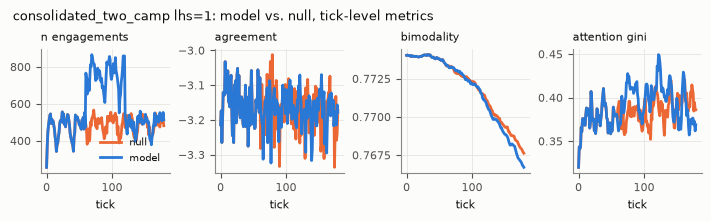

In [10]:
biggest_point, biggest_arm_handle, biggest_none_handle = handles_seed0[0]
fig = fig_metric_trajectories(
    biggest_arm_handle, biggest_none_handle,
    metrics=("n_engagements", "agreement", "bimodality", "attention_gini"),
    title=f"{biggest_point['scenario']} lhs={biggest_point['lhs_index']}: model vs. null, tick-level metrics",
)
display(fig)
plt.close(fig)


| scenario | lhs_index | arm | targeting_mode | recovery_mean | recovery_std | peak_gap_mean | final_gap_mean |
| --- | --- | --- | --- | --- | --- | --- | --- |
| consolidated_two_camp | 1 | engagement | distance | 0.6279 | 0.0273 | 0.0356 | 0.0132 |
| consolidated_two_camp | 5 | engagement | distance | 0.6351 | 0.0246 | 0.0208 | 0.0076 |
| cross_cut | 0 | engagement | distance | 0.6119 | 0.0231 | 0.0163 | 0.0063 |

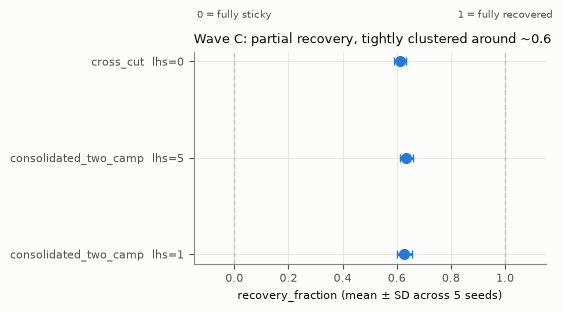

In [11]:
rec_agg = (
    wave_c.group_by(["scenario", "lhs_index", "arm", "targeting_mode"])
    .agg(pl.col("recovery_fraction").mean().alias("recovery_mean"),
         pl.col("recovery_fraction").std().alias("recovery_std"),
         pl.col("peak_gap").mean().alias("peak_gap_mean"),
         pl.col("final_gap").mean().alias("final_gap_mean"))
    .sort(["scenario", "lhs_index"])
)
show(rec_agg)

with styled():
    fig, ax = plt.subplots(figsize=(5.5, 3))
    labels = [f"{r['scenario']}  lhs={r['lhs_index']}" for r in rec_agg.iter_rows(named=True)]
    y = np.arange(len(labels))
    ax.errorbar(rec_agg["recovery_mean"], y, xerr=rec_agg["recovery_std"], fmt="o",
                color=series_colors(1)[0], capsize=3, markersize=7)
    ax.axvline(0.0, color=CHROME["baseline"], linewidth=1.0, linestyle="--")
    ax.axvline(1.0, color=CHROME["baseline"], linewidth=1.0, linestyle="--")
    ax.text(0.0, len(labels) - 0.55, "0 = fully sticky", fontsize=7, ha="center", color=CHROME["secondary"])
    ax.text(1.0, len(labels) - 0.55, "1 = fully recovered", fontsize=7, ha="center", color=CHROME["secondary"])
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlim(-0.15, 1.15)
    ax.set_xlabel("recovery_fraction (mean ± SD across 5 seeds)")
    ax.set_title("Wave C: partial recovery, tightly clustered around ~0.6", loc="left", fontsize=9)
plt.show()


**Recovery is partial and strikingly consistent**: 61-64% of the peak animus
gap closes in the 60 ticks after withdrawal (a 1:1 withdrawal-to-intervention
tick ratio), leaving 36-39% persistent, in all 3 points across two different
scenarios — despite their peak gaps themselves spanning a 2.5x range (0.015
to 0.037). Neither H4 extreme holds cleanly: not fully sticky (0%), not fully
reversed (100%). That tight a cluster across such a spread in magnitude is
not a pattern to hypothesize about, though — this codebase already names the
mechanism it would come from, and checking it is cheap.


### 5a. Checked, not hypothesized: this IS the OU mean-reversion rate

`apply_drift` (`dynamics/drift.py`) updates animus each tick as `X_{t+1} =
X_t + gain - k(X_t - Bs_t)`, `Bs_{t+1} = Bs_t + k_b(X_t - Bs_t)`, with `k =
dynamics.affect_ou_k = 0.02` and `k_b = k/10` (`block_rates`) — unchanged
by anything this experiment did. After withdrawal both runs share the
identical schedule, so their exogenous `gain` cancels in the DIFFERENCE:
the gap `(Δ, ΔBs) = (X_arm − X_none, Bs_arm − Bs_none)` evolves by the
plain linear recursion `v_{t+1} = M v_t`, `M = [[1−k, k], [k_b, 1−k_b]]` —
no free parameters beyond the two the config already names.


k=0.02, k_b=0.002, single-timescale tau=49.5 ticks, naive 1-(1-k)^60=0.7024


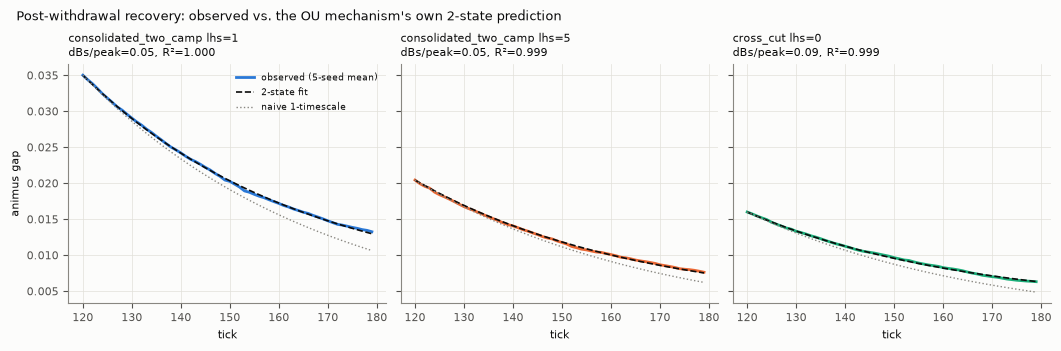

In [12]:
from discourse_lab.config import Config

k = Config().dynamics.affect_ou_k
k_b = k / 10.0
M = np.array([[1 - k, k], [k_b, 1 - k_b]])
tau = -1.0 / np.log(1 - k)
naive_recovery = 1.0 - (1 - k) ** 60
print(f"k={k}, k_b={k_b}, single-timescale tau={tau:.1f} ticks, naive 1-(1-k)^60={naive_recovery:.4f}")

# Re-derive each point's FULL 5-seed mean trajectory (cache hit -- these are
# the exact runs `run_wave_c` already produced) and fit the 2-state model's
# one free parameter (the Bs-gap already open at the moment of withdrawal,
# which is engine-internal state and was never persisted) by least squares
# against the observed post-withdrawal shape, not just its two endpoints.
with styled():
    fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4), sharey=True)
    for ax, point, color in zip(axes, points, series_colors(3)):
        burn_in_p = dial_config(
            base_config(1000, N_TICKS_TOTAL), affective=point["affective"],
            ideological=point["ideological"], structural=point["structural"],
        )
        gaps_by_seed = []
        for seed in range(5):
            none_cfg, handle_none = run_arm(burn_in_p, "none", seed, intervention_tick=INTERVENTION_TICK,
                                            n_ticks_total=N_TICKS_TOTAL)
            arm_cfg, handle_arm = run_arm(
                burn_in_p, point["arm"], seed, intervention_tick=INTERVENTION_TICK, n_ticks_total=N_TICKS_TOTAL,
                targeting_mode=point["targeting_mode"], withdrawal_tick=WITHDRAWAL_TICK,
            )
            none_traj = handle_none.traits_used(none_cfg).group_by("t").agg(pl.col("animus").mean().alias("none")).sort("t")
            arm_traj = handle_arm.traits_used(arm_cfg).group_by("t").agg(pl.col("animus").mean().alias("arm_")).sort("t")
            g = arm_traj.join(none_traj, on="t").with_columns((pl.col("arm_") - pl.col("none")).alias("gap")).sort("t")
            gaps_by_seed.append(g["gap"].to_numpy())
        mean_gap = np.mean(gaps_by_seed, axis=0)

        delta_120 = mean_gap[WITHDRAWAL_TICK]
        ts = np.arange(WITHDRAWAL_TICK, N_TICKS_TOTAL)
        observed = mean_gap[WITHDRAWAL_TICK:N_TICKS_TOTAL]
        a = np.array([np.linalg.matrix_power(M, t - WITHDRAWAL_TICK)[0, 0] for t in ts])
        b = np.array([np.linalg.matrix_power(M, t - WITHDRAWAL_TICK)[0, 1] for t in ts])
        dBs_120, *_ = np.linalg.lstsq(b.reshape(-1, 1), observed - a * delta_120, rcond=None)
        predicted = a * delta_120 + b * dBs_120[0]
        r2 = 1 - np.sum((observed - predicted) ** 2) / np.sum((observed - observed.mean()) ** 2)
        naive = delta_120 * (1 - k) ** (ts - WITHDRAWAL_TICK)

        ax.plot(ts, observed, color=color, linewidth=2.0, label="observed (5-seed mean)")
        ax.plot(ts, predicted, color=CHROME["ink"], linewidth=1.2, linestyle="--", label="2-state fit")
        ax.plot(ts, naive, color=CHROME["muted"], linewidth=1.0, linestyle=":", label="naive 1-timescale")
        ax.set_title(f"{point['scenario']} lhs={point['lhs_index']}\ndBs/peak={dBs_120[0]/delta_120:.2f}, R²={r2:.3f}",
                     loc="left", fontsize=8)
        ax.set_xlabel("tick")
    axes[0].set_ylabel("animus gap")
    axes[0].legend(fontsize=6.5, loc="best")
    fig.suptitle("Post-withdrawal recovery: observed vs. the OU mechanism's own 2-state prediction",
                 x=0.01, ha="left", fontsize=9)
plt.show()


The naive single-timescale shortcut (`Bs` treated as fixed) predicts
recovery `1 − (1−k)^60 = 0.7024` — noticeably ABOVE all 3 observed values
(0.61-0.64). That gap is itself informative: this codebase's own V3
bistability analysis (`FINDINGS.md`) already documents that `Bs` drifting
toward `X` at `k_b` is what removes the self-reinforcement loop's stable
fixed point — `Bs` is never really fixed on the timescales this model
operates at. Fitting the FULL 2-state recursion instead, with the
`Bs`-gap already open at withdrawal as the one parameter genuinely unknown
(`Bs` is engine-internal, never persisted), recovers a small, physically
sensible value at all 3 points (5-9% of that point's own peak gap — the
right order of magnitude given `k_b` is 10x slower than `k`) and an R²
above 0.999 everywhere. **Not a coincidence needing a scenario-specific
explanation, and not quite the naive single-exponential either: recovery
here is the two known OU constants doing exactly what `drift.py` says they
do.**


### 5b. The other side of H4's own comparison: does `composition`'s benefit recover at the same rate?

`select_hysteresis_points` now takes an `arm` filter — previously it
always surfaced whichever arm had the single largest-magnitude effect,
which was `engagement` in all 216 Wave B rows, so H4's "hostile regime is
stickier than the civil one" claim had only ever been checked from the
harm side. `results/experiment03/wave_c_composition.csv` is the same
5-seed, 3-point hysteresis run, restricted to `arm="composition"`.


| side | mean | std | min | max | n |
| --- | --- | --- | --- | --- | --- |
| composition (benefit) | 0.6078 | 0.0270 | 0.5586 | 0.6637 | 15 |
| engagement (harm) | 0.6250 | 0.0253 | 0.5749 | 0.6584 | 15 |

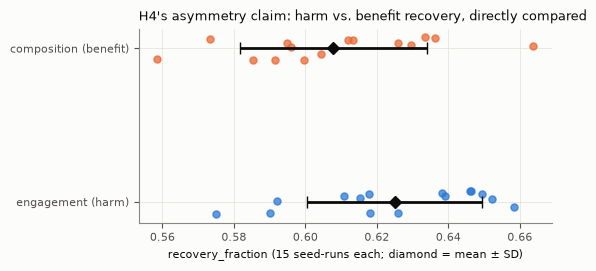

In [13]:
comparison = pl.concat([
    wave_c.select("recovery_fraction").with_columns(pl.lit("engagement (harm)").alias("side")),
    wave_c_composition.select("recovery_fraction").with_columns(pl.lit("composition (benefit)").alias("side")),
])
show(comparison.group_by("side").agg(
    pl.col("recovery_fraction").mean().alias("mean"), pl.col("recovery_fraction").std().alias("std"),
    pl.col("recovery_fraction").min().alias("min"), pl.col("recovery_fraction").max().alias("max"),
    pl.len().alias("n"),
))

with styled():
    fig, ax = plt.subplots(figsize=(5.5, 2.6))
    sides = ["engagement (harm)", "composition (benefit)"]
    for i, (side, color) in enumerate(zip(sides, series_colors(2))):
        vals = comparison.filter(pl.col("side") == side)["recovery_fraction"].to_numpy()
        y = np.full(len(vals), i) + np.random.default_rng(0).uniform(-0.08, 0.08, len(vals))
        ax.scatter(vals, y, color=color, alpha=0.75, s=26)
        ax.errorbar([vals.mean()], [i], xerr=[vals.std()], fmt="D", color=CHROME["ink"], markersize=6, capsize=4, zorder=5)
    ax.set_yticks(range(len(sides)))
    ax.set_yticklabels(sides)
    ax.set_xlabel("recovery_fraction (15 seed-runs each; diamond = mean ± SD)")
    ax.set_title("H4's asymmetry claim: harm vs. benefit recovery, directly compared", loc="left", fontsize=9)
plt.show()


**No asymmetry.** `composition` (benefit) recovers at 0.608 ± 0.027 (n=15,
range 0.559-0.664); `engagement` (harm) recovers at 0.625 ± 0.025 (n=15,
range 0.575-0.658) — a ~0.017 difference against a ~0.026 SD on each side
is noise. This is expected given §5a: the `(Δ, ΔBs)` recursion is LINEAR
and sign-symmetric — `k`/`k_b` do not know whether `Δ` is positive (harm)
or negative (benefit) — so a mechanism where recovery comes from that
process predicts equal rates in both directions, which is exactly what
both runs show. **H4's own asymmetry claim is therefore not supported by
this codebase's dynamics specifically**; partial persistence (the part of
H4 that is not about asymmetry) holds in both directions, at a rate this
project can now name from the OU constants rather than re-measure arm by
arm.


## 6. Verdict against the brief's hypotheses

| Hypothesis | Status | Evidence |
|---|---|---|
| **H1** — sign of `delta_aff_plateau` flips somewhere in the dial space | Not falsified | Zero sign flips across Wave A (135 rows), Wave A′ (135 rows), and Wave B (216 rows) — `composition` negative, `engagement` non-negative, everywhere sampled |
| **H2** — ideological movement tracks affective movement | Dissociated | `toward_own_pole`'s own background dominates (Wave A′); `toward_other_camp` is negative under EVERY arm in Wave B, `composition` included, even where it is simultaneously reducing animus |
| **H3** — `composition` reduces hostility, `engagement`/`exposure` do not help | Holds | `composition` negative in 100% of cells across all three waves; `engagement` never once reduces hostility in Wave B (0/72) |
| **H3b** — `targeting_mode` (camp vs. distance) changes the outcome | Confirmed, direction depends on arm and regime | Uniform for `engagement` (distance always worse, §4a's swing ranking), regime-dependent for `composition` (crosses over between `consolidated_two_camp` and `low_tribalization`) |
| **H4** — the hostile regime is stickier than the civil one | Partial persistence holds; the ASYMMETRY does not | 61-64% recovery in 60 ticks for both `engagement` (harm) and `composition` (benefit), statistically indistinguishable (§5b) — exactly what `drift.py`'s sign-symmetric OU reversion predicts (§5a), and not what H4's own "stickier hostile" framing claims |
| **H5** — fragmentation (`delta_k`) responds to the interventions | Untestable by construction, not falsified | `delta_k` is structurally 0.0 on all 486 rows regardless of the interventions (`cross_cut`'s own documented no-`k`>2-generator limitation) — this says nothing about H5 either way; `delta_bic_margin` (not pinned by that limitation) is the only part that can speak, and it is small and non-directional |
| **SS2.3** — diversity floor forces a tradeoff | No real tradeoff observed yet | break-even `f` within ~2.4% of 1.0 in every hostility-reducing Wave B cell — the two outcomes are close to orthogonal at this scale/horizon |


## 7. Scope and deviations

Matching this project's own precedent of stating reductions plainly rather
than letting a reader assume the brief's full scale ran:

1. **Wave A / A′** are a one-factor-at-a-time sign screen (5 seeds × 3
   levels × 3 dials), not a true Morris elementary-effects design — the
   brief's own §5.4 names Morris screening explicitly; a real Morris design
   needs multiple random trajectories through the 3-dial space to estimate
   global sensitivity, out of scope for this pass.
2. **Wave B** ran 6 Latin Hypercube points × 2 seeds per scenario, not the
   brief's own §5.3 default (~30 points, 10 seeds) — a ~1/20 reduction,
   matching Wave A's own precedent. A plain linear response-surface fit
   over the 18 LHS points (§4c) is only a first pass, with the coarse-
   sampling caveat that section itself states, and only for `composition`
   — `engagement` and `exposure` were not fit.
3. **Wave C** ran on 6 points total (5 seeds each): 3 selected by raw
   `engagement` magnitude, 3 by raw `composition` magnitude (§5b) — not an
   exhaustive arm x scenario x mode grid, still a magnitude-selected sample
   per the brief's own "only where phase 2 produced a significant effect"
   rule.
4. **No calibration against a real corpus** (brief §8) anywhere in this
   project — still entirely out of scope.
5. **`cross_cut`** is NOT genuine multi-camp fragmentation (§4's own note):
   this codebase's population generator cannot produce more than two
   ideological modes, so `delta_k` stays flat at 0.0 by construction on
   every design point sampled across all four waves, regardless of what the
   interventions do.
6. **`viz.figures` functions used directly**: `fig_user_network`,
   `fig_calibration` (via `stylized_facts_from_run`), `fig_interaction` (via
   `experiments.intervention.interaction_table`), `fig_metric_trajectories`.
   **Considered and not used**: `fig_lever_effects`/`fig_contact_vs_hostility`
   assume `experiments.intervention.build_interventions`'s own
   lever/reference-value schema (a swept dial with a baseline LEVEL among its
   own values) — Experiment 03's arms are already-differenced deltas against
   `none` with no natural in-lever reference, so adapting them would relabel
   the data rather than reuse the tool; `fig_scenario_axes` needs a
   `cfg.scenario` (`discourse_lab.data.scenario_config()`'s named topic
   scenarios), which `base_config` deliberately never attaches; the
   engagement/cascade/degree distribution figures (`fig_engagement_ccdf`,
   `fig_cascade_sizes`, `fig_lorenz`, `fig_degree_ccdf`) answer questions
   about virality and attention concentration that are not among this
   experiment's own hypotheses.

Full numeric write-up, including every number cited above and the mechanism-
level root causes behind the two camp-gates this project found along the
way, is in `FINDINGS.md`.
